# Анализ таргетов участник 1

В этом ноутбуке сравниваем текущий таргет длины следующей сессии, таргет средней длины будущих сессий за 7 дней и два дополнительных кандидатных таргета. Цель анализа - понять устойчивость, шум, хвосты и практическую пригодность таргетов для следующих модельных ноутбуков.

## Критерии сравнения

Смотрим на форму распределения, устойчивость по времени, чувствительность к хвостам и поведение простых наивных предикторов. Финально оставляем сравнительный вывод без выбора единственного победителя.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if repo_root.name != 'ml_in_gamedev_project':
    for p in [repo_root, *repo_root.parents]:
        if p.name == 'ml_in_gamedev_project':
            repo_root = p
            break
sys.path.append(str(repo_root))

from preprocessing.preprocessing import load_data, add_crm_target_7d, regression_metrics

pd.set_option('display.max_columns', 120)

## Загрузка и срез

Берем около 100 тысяч последних наблюдений по времени, чтобы сохранить репрезентативность и не перегружать ноутбук.

In [2]:
df = load_data()
df = df.copy()
df['start'] = pd.to_datetime(df['start'], errors='coerce')
df = df[df['start'].notna()].sort_values('start').tail(100000).reset_index(drop=True)
df.shape

(100000, 84)

## Формирование таргетов

Кроме основного таргета из проекта добавляем три доп кандидата

Дополнительные кандидаты:
- средняя длина будущих сессий за 7 дней
- суммарное время будущих сессий за 7 дней
- доля длинных сессий в будущем окне 7 дней, где длинная сессия больше 1200 секунд

In [14]:
df = add_crm_target_7d(df, target_col='future_sessions_mean_playtime_7d', horizon_days=7)

def add_total_and_long_share_7d(x):
    y = x.copy()
    y = y[y['installation_id'].notna()].copy()
    y = y.sort_values(['installation_id', 'start']).reset_index(drop=True)

    sec_day = 24 * 3600
    delta_ns = np.int64(7 * sec_day * 1_000_000_000)
    dur = pd.to_numeric(y['duration_seconds'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
    long_flag = (dur > 1200).astype(float)

    fut_total = np.zeros(len(y), dtype=float)
    fut_long_share = np.zeros(len(y), dtype=float)
    fut_cnt = np.zeros(len(y), dtype=int)

    for _, idx in y.groupby('installation_id', sort=False).indices.items():
        idx = np.asarray(idx, dtype=np.int64)
        t = y.iloc[idx]['start'].values.astype('datetime64[ns]').astype(np.int64)
        d = dur[idx]
        lf = long_flag[idx]
        n = len(idx)

        nxt = np.arange(n, dtype=np.int64) + 1
        r = np.searchsorted(t, t + delta_ns, side='right')
        cnt = np.maximum(r - nxt, 0)
        fut_cnt[idx] = cnt

        csum_d = np.concatenate(([0.0], np.cumsum(d)))
        csum_l = np.concatenate(([0.0], np.cumsum(lf)))

        s_d = csum_d[r] - csum_d[np.minimum(nxt, n)]
        s_l = csum_l[r] - csum_l[np.minimum(nxt, n)]

        fut_total[idx] = s_d
        fut_long_share[idx] = np.divide(s_l, cnt, out=np.zeros_like(s_l), where=cnt > 0)

    max_t_ns = y['start'].max().value
    cut_ns = max_t_ns - delta_ns
    observed = y['start'].values.astype('datetime64[ns]').astype(np.int64) <= cut_ns

    y['future_sessions_total_playtime_7d'] = np.where(observed, fut_total, np.nan)
    y['future_long_share_7d'] = np.where(observed, fut_long_share, np.nan)
    return y

df = add_total_and_long_share_7d(df)

In [4]:
target_cols = [
    'target_next_session_length_sec',
    'future_sessions_mean_playtime_7d',
    'future_sessions_total_playtime_7d',
    'future_long_share_7d',
]

df[target_cols].isna().mean().rename('na_rate')

target_next_session_length_sec       0.00000
future_sessions_mean_playtime_7d     0.70597
future_sessions_total_playtime_7d    0.70597
future_long_share_7d                 0.70597
Name: na_rate, dtype: float64

## Временной split 70 15 15



In [5]:
n = len(df)
i1 = int(n * 0.70)
i2 = int(n * 0.85)

train_df = df.iloc[:i1].copy()
val_df = df.iloc[i1:i2].copy()
test_df = df.iloc[i2:].copy()

pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)]
})

,split,rows
0,train,70000
1,val,15000
2,test,15000


## Распределения и хвосты

Для каждого таргета считаем базовые статистики и оцениваем вклад тяжелого хвоста в общую массу значений.

In [6]:
def dist_stats(s):
    x = pd.to_numeric(s, errors='coerce').dropna().astype(float)
    q = x.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.995])
    iqr = float(q.loc[0.75] - q.loc[0.25])

    x_sorted = np.sort(x.values)
    total = float(x_sorted.sum()) if len(x_sorted) else 0.0

    def top_share(fr):
        if len(x_sorted) == 0 or total <= 0:
            return np.nan
        k = max(1, int(np.ceil(len(x_sorted) * fr)))
        return float(x_sorted[-k:].sum() / total)

    return {
        'count': len(x),
        'mean': float(x.mean()),
        'median': float(q.loc[0.5]),
        'std': float(x.std(ddof=1)),
        'iqr': iqr,
        'p90': float(q.loc[0.9]),
        'p95': float(q.loc[0.95]),
        'p99': float(q.loc[0.99]),
        'p995': float(q.loc[0.995]),
        'top_1pct_mass_share': top_share(0.01),
        'top_05pct_mass_share': top_share(0.005),
        'top_01pct_mass_share': top_share(0.001),
    }

rows = []
for t in target_cols:
    d = dist_stats(train_df[t])
    d['target'] = t
    rows.append(d)

dist_table = pd.DataFrame(rows)
dist_table[['target', 'count', 'mean', 'median', 'std', 'iqr', 'p90', 'p95', 'p99', 'p995', 'top_1pct_mass_share', 'top_05pct_mass_share', 'top_01pct_mass_share']]

,target,count,mean,median,std,iqr,p90,p95,p99,p995,top_1pct_mass_share,top_05pct_mass_share,top_01pct_mass_share
0,target_next_session_length_sec,70000,667.062771,301.000000,1360.004121,723.000000,1662.000000,2455.050000,4785.110,6112.000000,0.125028,0.084809,0.038033
1,future_sessions_mean_playtime_7d,20944,579.474500,466.211111,528.639867,521.173118,1190.616667,1529.972093,2516.745,3075.203571,0.057676,0.033743,0.009388
2,future_sessions_total_playtime_7d,20944,16259.233766,8527.000000,22944.053910,18619.750000,41601.100000,61313.200000,119499.380,136618.360000,0.088086,0.048725,0.011292
3,future_long_share_7d,20944,0.141980,0.071429,0.186676,0.217391,0.395504,0.500000,1.000,1.000000,0.070621,0.035311,0.007062


Нарисуем ка

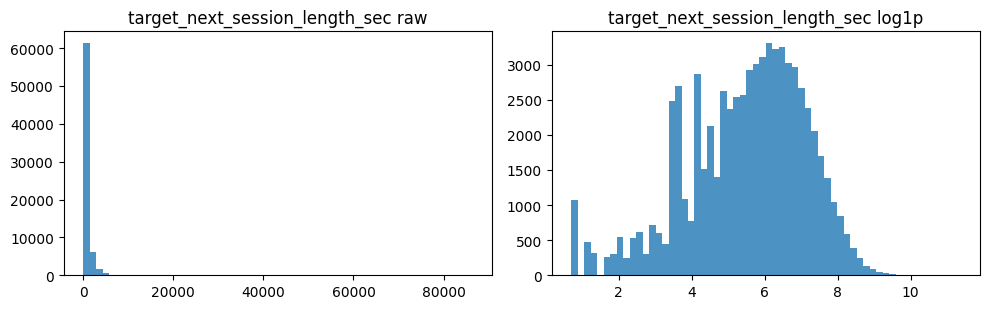

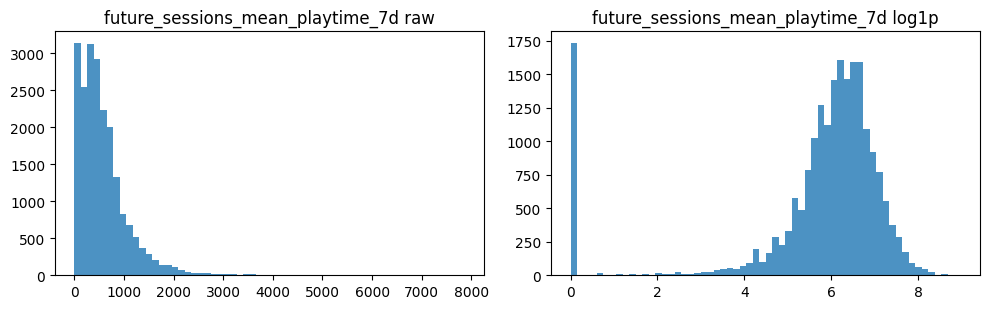

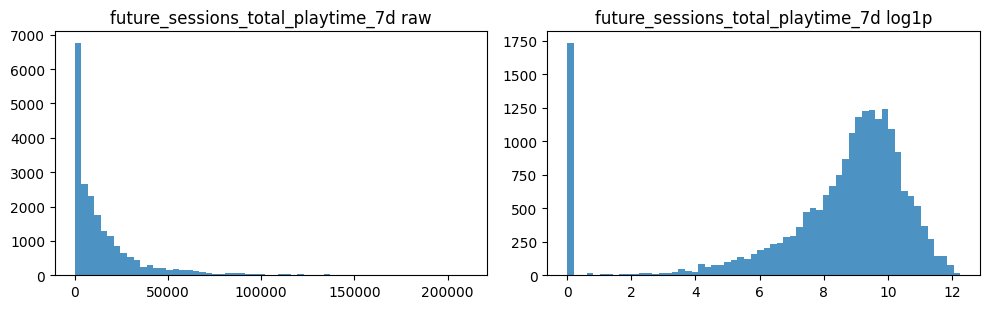

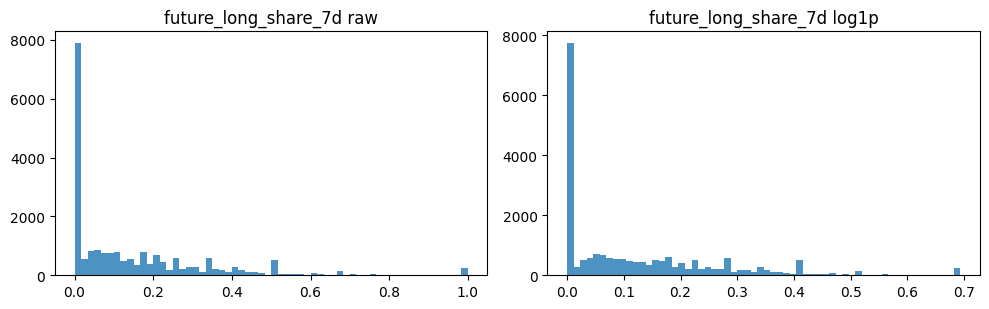

In [7]:
for t in target_cols:
    x = pd.to_numeric(train_df[t], errors='coerce').dropna().astype(float)
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
    ax[0].hist(x, bins=60, alpha=0.8)
    ax[0].set_title(t + ' raw')
    ax[1].hist(np.log1p(np.clip(x, 0, None)), bins=60, alpha=0.8)
    ax[1].set_title(t + ' log1p')
    plt.tight_layout()
    plt.show()

## Noise и устойчивость в формате theory lite

Оцениваем шум и стабильность через drift между train val test и через вариативность на rolling окнах времени.

In [8]:
def split_moment_table(t):
    out = []
    for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
        x = pd.to_numeric(part[t], errors='coerce').dropna().astype(float)
        out.append({
            'target': t,
            'split': name,
            'mean': float(x.mean()),
            'median': float(x.median()),
            'std': float(x.std(ddof=1)),
            'p95': float(x.quantile(0.95)),
            'p99': float(x.quantile(0.99)),
        })
    return pd.DataFrame(out)

drift_rows = []
for t in target_cols:
    drift_rows.append(split_moment_table(t))
drift_table = pd.concat(drift_rows, ignore_index=True)
drift_table

,target,split,mean,median,std,p95,p99
0,target_next_session_length_sec,train,667.062771,301.000000,1360.004121,2455.050000,4785.110000
1,target_next_session_length_sec,val,712.616200,300.000000,2551.329420,2381.100000,4913.250000
2,target_next_session_length_sec,test,704.641933,303.000000,1965.102087,2511.300000,4897.280000
3,future_sessions_mean_playtime_7d,train,579.474500,466.211111,528.639867,1529.972093,2516.745000
4,future_sessions_mean_playtime_7d,val,568.558440,461.850000,545.597250,1498.522074,2501.758571
5,future_sessions_mean_playtime_7d,test,673.329503,498.708333,719.296537,2039.006818,3424.314222
6,future_sessions_total_playtime_7d,train,16259.233766,8527.000000,22944.053910,61313.200000,119499.380000
7,future_sessions_total_playtime_7d,val,13046.940214,7804.000000,15117.852838,48825.600000,67162.740000
8,future_sessions_total_playtime_7d,test,13003.948522,7447.500000,15774.065917,46021.100000,72143.360000
9,future_long_share_7d,train,0.141980,0.071429,0.186676,0.500000,1.000000


Видно, что у future_sessions_mean_playtime_7d из первых трех метрик наименьший разброс. Плюс классный график

Таргет суммы будущих сессий за 7 дней в сессионной постановке плохо отражает поведение типичного игрока: на уровне сессий медиана получается высокой, потому что самые активные пользователи попадают в выборку много раз и непропорционально сильно влияют на статистику, а на уровне игроков медиана заметно ниже. Из-за этого таргет оказывается смещенным в сторону “тяжелых” пользователей, нестабильно ведет себя по хвостам. В общем этот таргет точно не берем

future_long_share_7d тоже не оч как основной таргет: почти все значения около нуля, есть редкие пики до 1.0 и в test он сдвигается вверх относительно train/val, значит таргет шумный и нестабильный


In [9]:
def rolling_var_proxy(t, window=8000, step=4000):
    x = pd.to_numeric(df[t], errors='coerce').astype(float)
    rows = []
    i = 0
    while i + window <= len(x):
        z = x.iloc[i:i+window].dropna()
        rows.append({
            'target': t,
            'start_idx': i,
            'mean': float(z.mean()),
            'median': float(z.median()),
            'p95': float(z.quantile(0.95)),
        })
        i += step
    return pd.DataFrame(rows)

rv = pd.concat([rolling_var_proxy(t) for t in target_cols], ignore_index=True)
rv.groupby('target')[['mean', 'median', 'p95']].std().rename(columns={'mean': 'rolling_std_mean', 'median': 'rolling_std_median', 'p95': 'rolling_std_p95'})

,rolling_std_mean,rolling_std_median,rolling_std_p95
target,,,
future_long_share_7d,0.009725,0.017203,0.032822
future_sessions_mean_playtime_7d,37.816532,50.146271,188.513910
future_sessions_total_playtime_7d,2652.730680,1236.264280,12769.581566
target_next_session_length_sec,50.451413,16.221463,92.300260


total_playtime_7d самый шумный и нестабильный, mean_playtime_7d норм как второй основной, next_session_length остается самым практичным базовым, long_share_7d лучше держать как вспомогательный индикатор, не как главный таргет

## Наивные baseline предикторы

Считаем простые предикторы, чтобы измерить чувствительность таргетов к хвостам и шуму.

In [10]:
def get_naive_preds(y_train, y_eval):
    yt = pd.Series(y_train).dropna().astype(float)
    ye = pd.Series(y_eval).dropna().astype(float)
    k = len(ye)
    p995 = float(yt.quantile(0.995))
    recent = yt.tail(min(3000, len(yt)))

    return {
        'global_mean': np.full(k, float(yt.mean())),
        'global_median': np.full(k, float(yt.median())),
        'recent_mean': np.full(k, float(recent.mean())),
        'clipped_mean_p995': np.full(k, float(np.minimum(yt, p995).mean())),
    }, ye.values

def sec_metrics(y_true, y_pred):
    m = regression_metrics(y_true, y_pred)
    return {
        'MAE': m['mae'],
        'MedAE': m['medae'],
        'P70': m['p70_abs_error'],
        'P90': m['p90_abs_error'],
        'R2': m['r2'],
        'small_mae': m['small_mae'],
        'normal_mae': m['normal_mae'],
        'long_mae': m['long_mae'],
        'ProductMAE': m['product_mae'],
        'EngagementRiskMAE': m['engagement_risk_mae'],
    }

def share_metrics(y_true, y_pred):
    e = np.abs(y_true - y_pred)
    med = np.median(e)
    p70 = np.percentile(e, 70)
    p90 = np.percentile(e, 90)
    sst = np.sum((y_true - y_true.mean())**2)
    sse = np.sum((y_true - y_pred)**2)
    r2 = float(1 - sse / sst) if sst > 0 else np.nan
    return {
        'MAE': float(np.mean(e)),
        'MedAE': float(med),
        'P70': float(p70),
        'P90': float(p90),
        'R2': r2,
        'small_mae': np.nan,
        'normal_mae': np.nan,
        'long_mae': np.nan,
        'ProductMAE': np.nan,
        'EngagementRiskMAE': np.nan,
    }

In [11]:
rows = []
for t in target_cols:
    tr = train_df[t]
    va = val_df[t]
    te = test_df[t]

    tr = pd.to_numeric(tr, errors='coerce')
    va = pd.to_numeric(va, errors='coerce')
    te = pd.to_numeric(te, errors='coerce')

    preds_va, yv = get_naive_preds(tr, va)
    preds_te, yt = get_naive_preds(tr, te)

    for name in preds_va:
        if t == 'future_long_share_7d':
            mv = share_metrics(yv, np.clip(preds_va[name], 0.0, 1.0))
            mt = share_metrics(yt, np.clip(preds_te[name], 0.0, 1.0))
        else:
            mv = sec_metrics(yv, np.maximum(preds_va[name], 0.0))
            mt = sec_metrics(yt, np.maximum(preds_te[name], 0.0))

        r = {'target': t, 'predictor': name}
        for k, v in mv.items():
            r['val_' + k] = v
        for k, v in mt.items():
            r['test_' + k] = v
        rows.append(r)

cmp_table = pd.DataFrame(rows).sort_values(['target', 'test_MAE']).reset_index(drop=True)
cmp_table

,target,predictor,val_MAE,val_MedAE,val_P70,val_P90,val_R2,val_small_mae,val_normal_mae,val_long_mae,val_ProductMAE,val_EngagementRiskMAE,test_MAE,test_MedAE,test_P70,test_P90,test_R2,test_small_mae,test_normal_mae,test_long_mae,test_ProductMAE,test_EngagementRiskMAE
0,future_long_share_7d,global_median,0.128426,0.071429,0.100000,0.317460,-0.129808,NaN,NaN,NaN,NaN,NaN,0.150969,0.071429,0.128571,0.390110,-0.174506,NaN,NaN,NaN,NaN,NaN
1,future_long_share_7d,global_mean,0.139904,0.141980,0.141980,0.246909,-0.000183,NaN,NaN,NaN,NaN,NaN,0.159256,0.141980,0.141980,0.319559,-0.008344,NaN,NaN,NaN,NaN,NaN
2,future_long_share_7d,clipped_mean_p995,0.139904,0.141980,0.141980,0.246909,-0.000183,NaN,NaN,NaN,NaN,NaN,0.159256,0.141980,0.141980,0.319559,-0.008344,NaN,NaN,NaN,NaN,NaN
3,future_long_share_7d,recent_mean,0.141127,0.146041,0.146041,0.242848,-0.001230,NaN,NaN,NaN,NaN,NaN,0.160371,0.146041,0.146041,0.315497,-0.005264,NaN,NaN,NaN,NaN,NaN
4,future_sessions_mean_playtime_7d,global_median,344.022759,232.288889,392.892222,719.279798,-0.035197,341.332253,191.263127,1304.609882,247.196986,262.007362,442.439532,280.875000,466.211111,974.987103,-0.082933,342.008602,212.537053,1575.039199,267.532973,284.690577
5,future_sessions_mean_playtime_7d,clipped_mean_p995,356.253036,264.338422,418.239960,610.152487,-0.000154,450.459564,175.275739,1195.482571,281.393499,297.999889,448.741474,319.161578,501.948422,865.859792,-0.018564,451.135912,190.500204,1465.911888,295.366978,320.827430
6,future_sessions_mean_playtime_7d,global_mean,357.258301,267.141166,421.434500,606.016409,-0.000400,454.595642,175.564998,1191.346494,283.127988,299.876636,449.523018,321.148496,504.857833,861.723715,-0.017030,455.271990,190.648167,1461.775811,296.732187,322.727556
7,future_sessions_mean_playtime_7d,recent_mean,364.531206,283.783575,435.558059,605.433059,-0.004569,480.554202,178.972999,1165.387934,294.130747,312.567230,455.063105,333.562500,507.796638,835.765155,-0.008912,481.230550,192.727249,1435.817251,309.419053,335.273734
8,future_sessions_total_playtime_7d,global_median,10466.148897,7488.000000,8527.000000,22354.800000,-0.089410,8490.694056,7799.585075,11045.547251,655.905907,8790.326368,10850.017488,7542.000000,8527.000000,24983.700000,-0.080572,8485.251309,7825.280453,11623.068922,677.401162,8832.594343
9,future_sessions_total_playtime_7d,clipped_mean_p995,12227.807500,11638.915957,15026.016809,16151.915957,-0.042192,16115.610013,15424.501031,11284.303671,655.905907,15087.171211,12751.900644,12599.415957,15447.015957,17358.784043,-0.039836,16110.167266,15450.196410,11833.973018,677.401162,15255.105379


Оставляем два таргета next_session_length и mean_playtime_7d.

future_sessions_total_playtime_7d показывает очень большие абсолютные ошибки и плохую стабильность

## Калибровка для таргета доли long сессий

Для будущей доли long сессий оцениваем калибровку на test через бины предсказаний.

In [12]:
t = 'future_long_share_7d'
tr = pd.to_numeric(train_df[t], errors='coerce').dropna()
te = pd.to_numeric(test_df[t], errors='coerce').dropna()

pred = np.full(len(te), float(tr.mean()))
pred = np.clip(pred, 0.0, 1.0)

cal = pd.DataFrame({'pred': pred, 'true': te.values})
cal['bin'] = pd.qcut(cal['pred'].rank(method='first'), q=10, labels=False)
cal_table = cal.groupby('bin', as_index=False).agg(pred_mean=('pred', 'mean'), true_mean=('true', 'mean'), n=('true', 'size'))
cal_table

,bin,pred_mean,true_mean,n
0,0,0.14198,0.152443,406
1,1,0.14198,0.193656,406
2,2,0.14198,0.172154,406
3,3,0.14198,0.147640,406
4,4,0.14198,0.137587,406
5,5,0.14198,0.134452,406
6,6,0.14198,0.190039,406
7,7,0.14198,0.189078,406
8,8,0.14198,0.107927,406
9,9,0.14198,0.192260,406


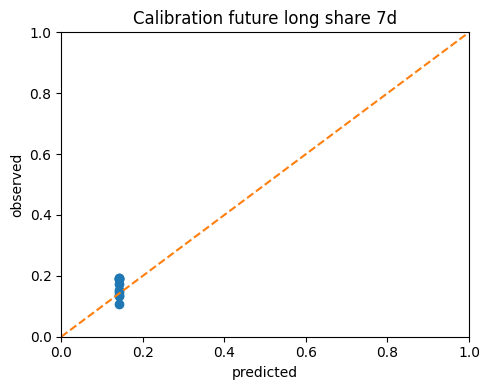

In [13]:
plt.figure(figsize=(5, 4))
plt.plot(cal_table['pred_mean'], cal_table['true_mean'], marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('Calibration future long share 7d')
plt.xlabel('predicted')
plt.ylabel('observed')
plt.tight_layout()
plt.show()

 Предиктор фактически константный: он в каждом бине дает одно и то же значение 0.14198 и не умеет разделять наблюдения по уровню риска. Поэтому различия в true_mean между бинами это в основном шум выборки а не реальная калибровка или полезное ранжирование модели

## Итоговое сравнение и вывод

Будем брать два таргета - длина следующей сессии и средняя длина будущих сессий за 7 дней.